In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# Plotting style
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

In [2]:
df = pd.read_excel("Concrete_Data.xls")

X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '], axis=1)
y= df['Concrete compressive strength(MPa, megapascals) '].values

N, M = X.shape

print(N, M)  # rows, columns

# Remove everything after the first '(' in each column name
X.columns = [col.split('(')[0].strip() for col in X.columns]

X.head()

1030 8


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


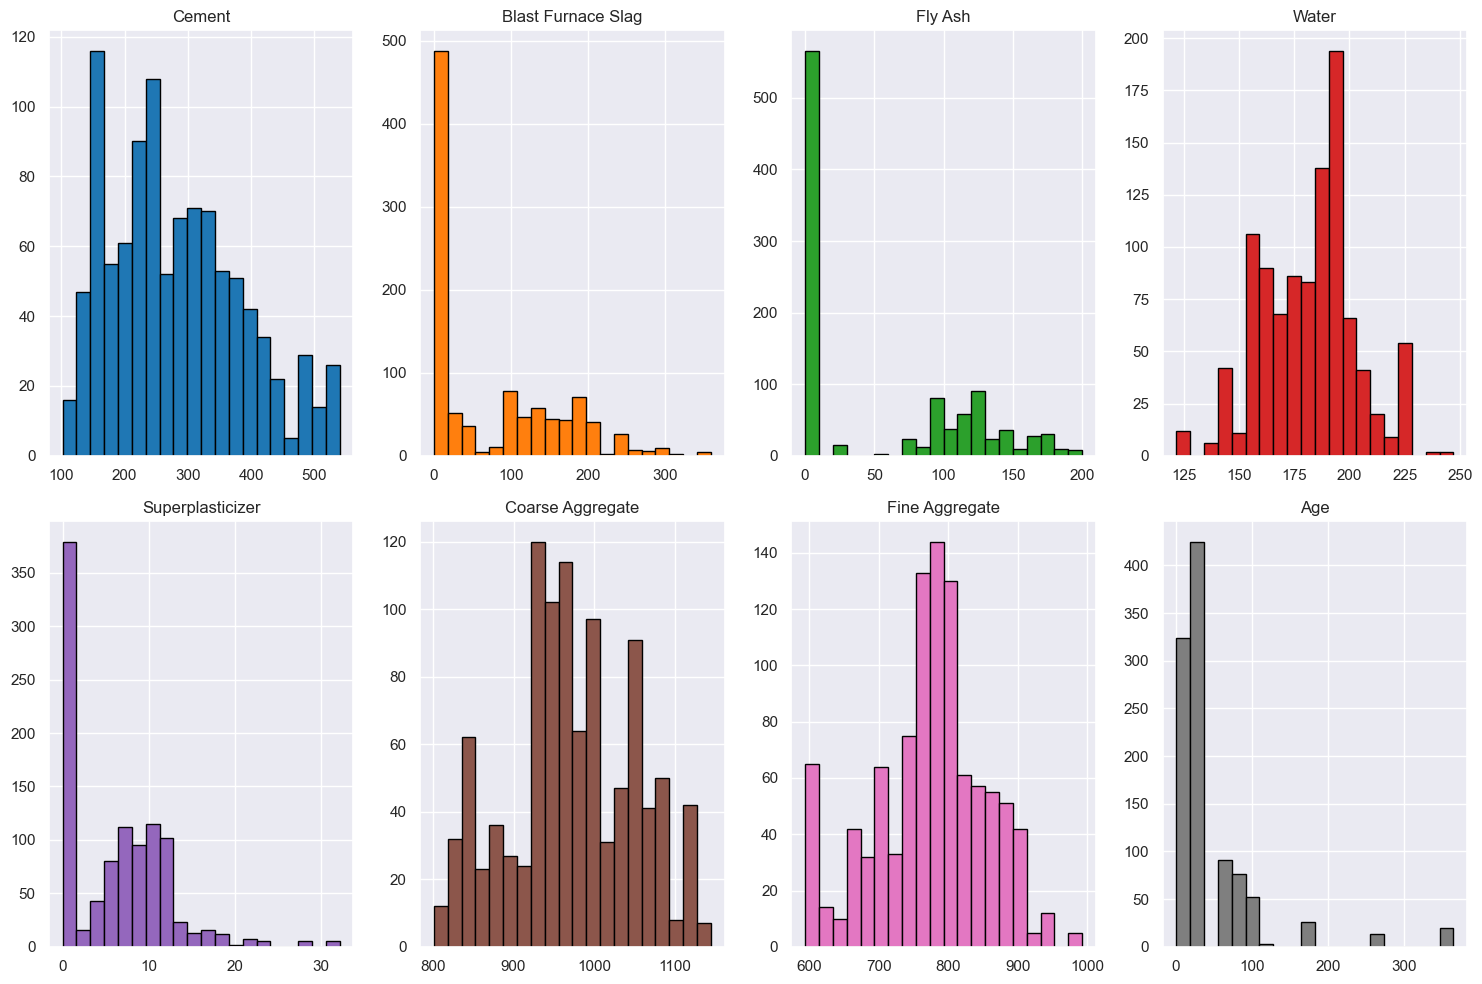

In [3]:
# pick 8 distinct colors for each feature
colors = [
    "tab:blue", "tab:orange", "tab:green", "tab:red",
    "tab:purple", "tab:brown", "tab:pink", "tab:gray"
]

fig, ax = plt.subplots(2, 4, figsize=(15, 10))
ax = ax.ravel()

for i in range(8):  # the first 8 columns (all features)
    ax[i].hist(X.iloc[:, i], bins=20, color=colors[i], edgecolor="black")
    ax[i].set_title(X.columns[i])

plt.tight_layout()
plt.show()

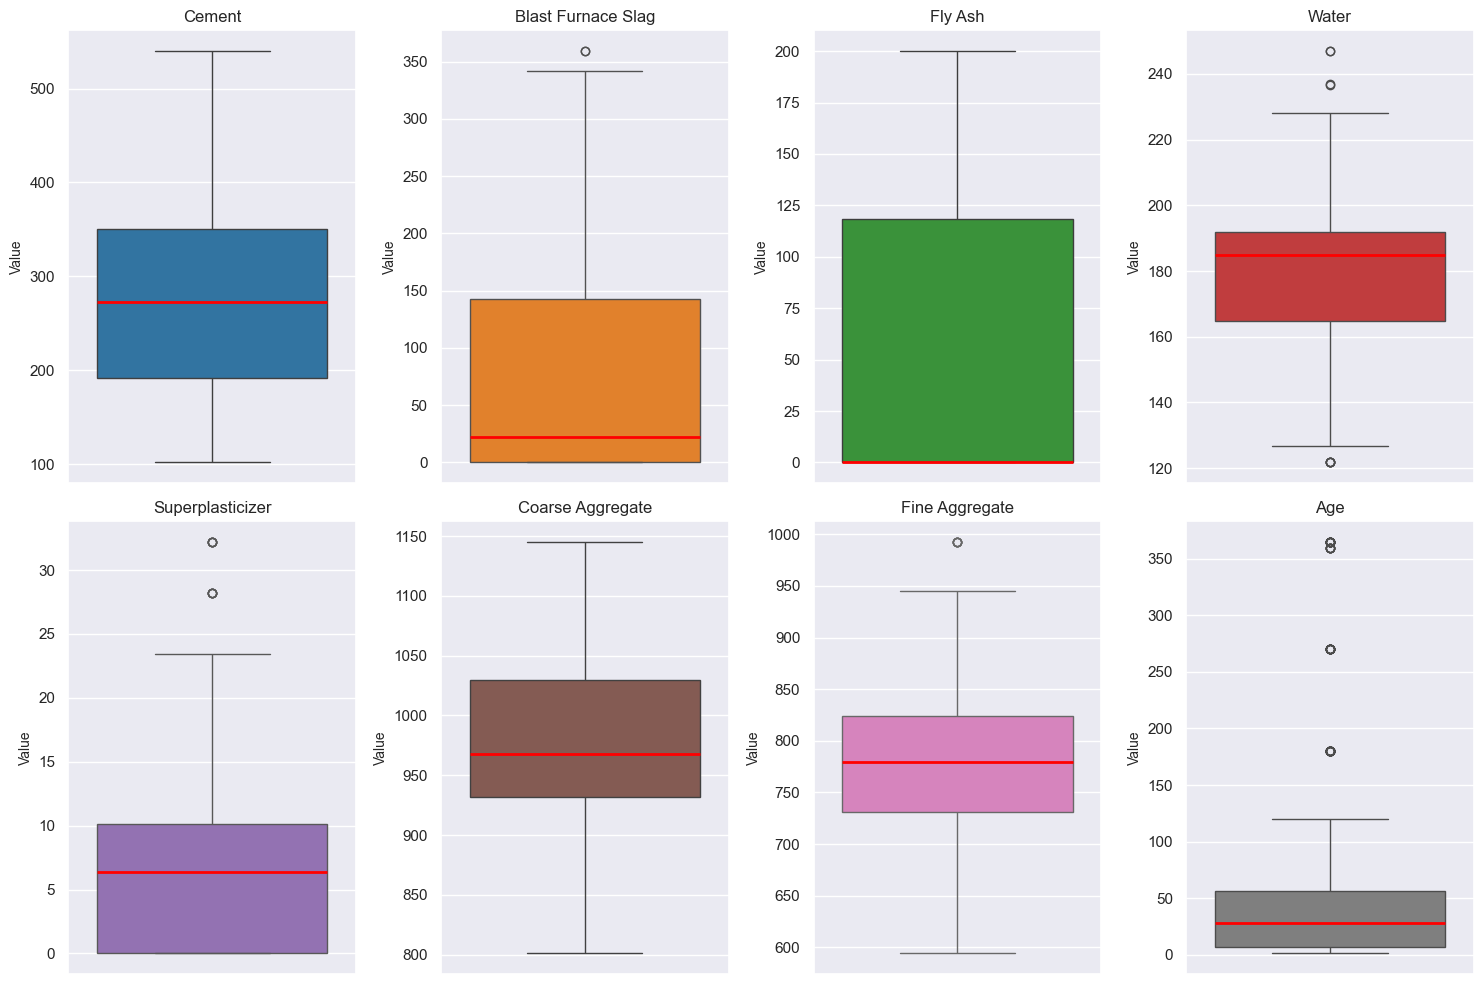

In [4]:
# Boxplots
fig, ax = plt.subplots(2, 4, figsize=(15, 10))
ax = ax.ravel()

for i in range(8):  # the first 8 columns
    sns.boxplot(
        y=X.iloc[:, i],
        ax=ax[i],
        color=colors[i],
        medianprops=dict(color='red', linewidth=2)  # set median line to red
    )
    ax[i].set_title(X.columns[i], fontsize=12)
    ax[i].set_xlabel("")  # optional, remove x-axis label
    ax[i].set_ylabel("Value", fontsize=10)


plt.tight_layout()
plt.show()


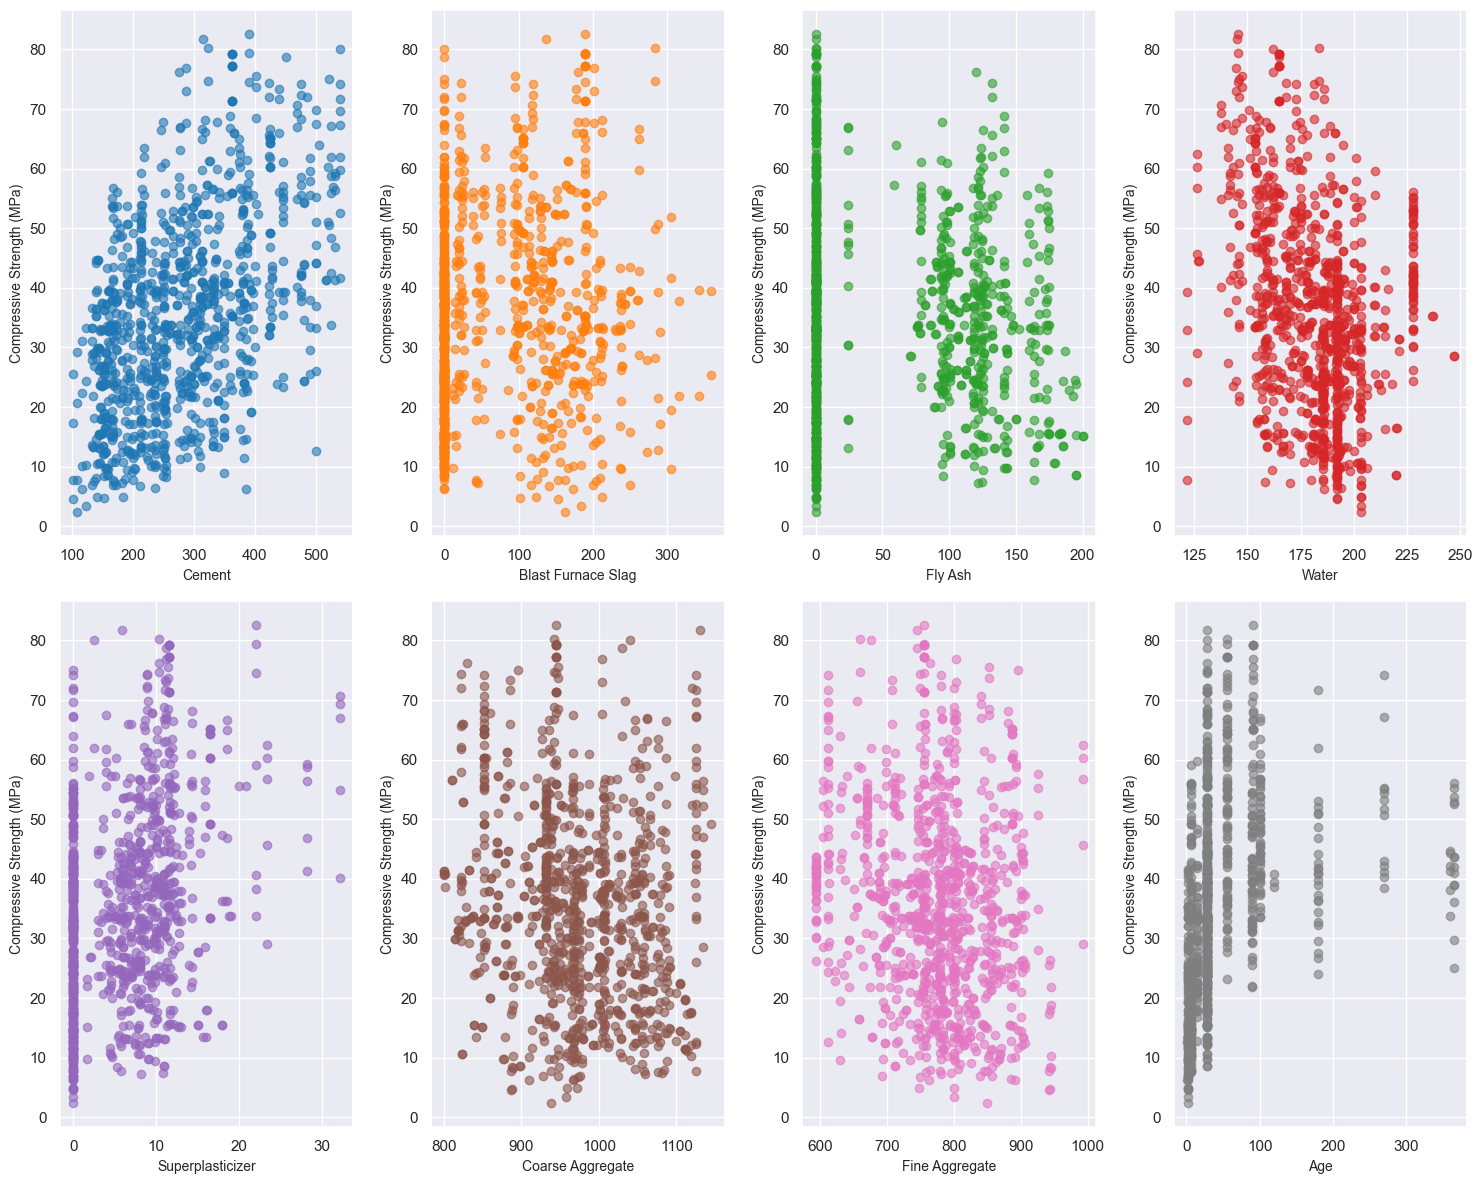

In [5]:
fig, ax = plt.subplots(2, 4, figsize=(15, 12))
ax = ax.ravel()

for i in range(8):  # only the first 8 columns
    ax[i].scatter(X.iloc[:, i], y, color=colors[i], alpha=0.6)
    ax[i].set_xlabel(X.columns[i], fontsize=10)
    ax[i].set_ylabel("Compressive Strength (MPa)", fontsize=10)
    ax[i].grid(True)


plt.tight_layout()
plt.show()

In [6]:
# Standard summary statistics
summary = X.describe()

# Calculate range for each column
range_ = X.max() - X.min()
range_.name = 'range'

# Append the range as a new row using pd.concat
summary_with_range = pd.concat([summary, range_.to_frame().T])

# Display the summary
summary_with_range

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000
range,438.000000,359.400000,200.100000,125.250000,32.200000,344.000000,398.600000,364.000000


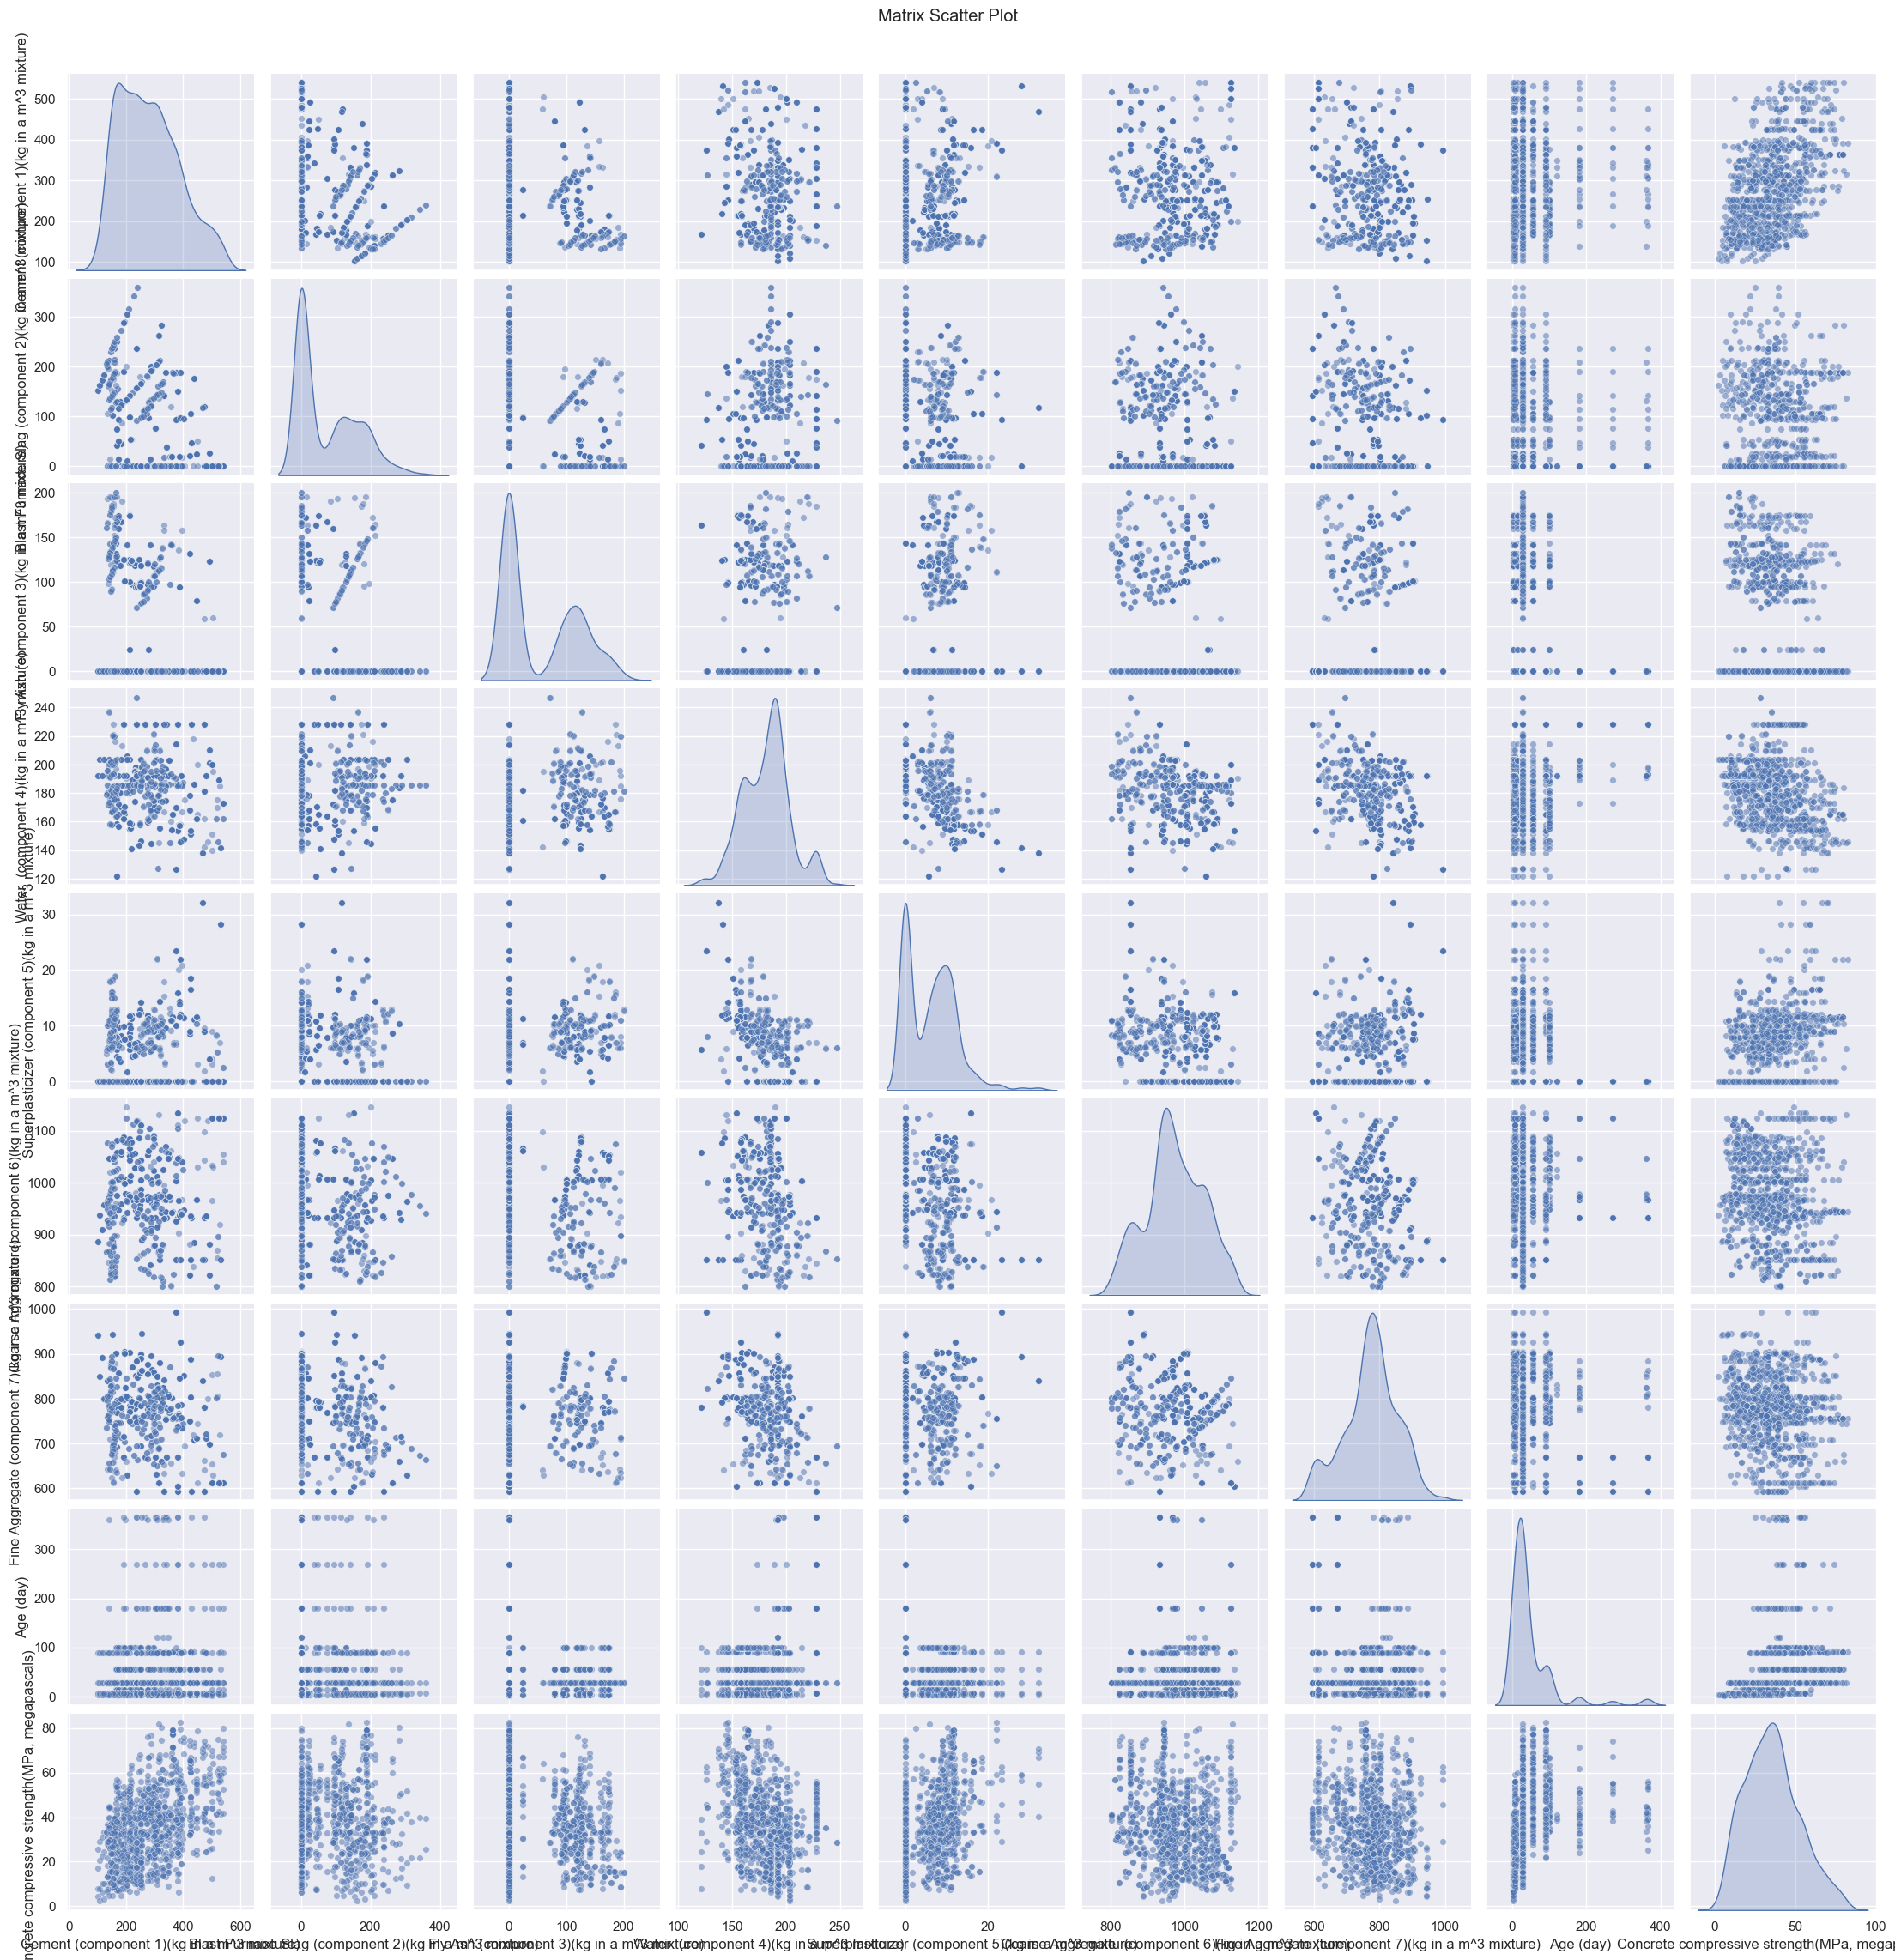

In [7]:
# Matrix scatter plot
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha':0.5, 's':30})
plt.suptitle("Matrix Scatter Plot", y=1.02)
plt.show()               

Text(0.5, 1.0, 'Correlation Matrix')

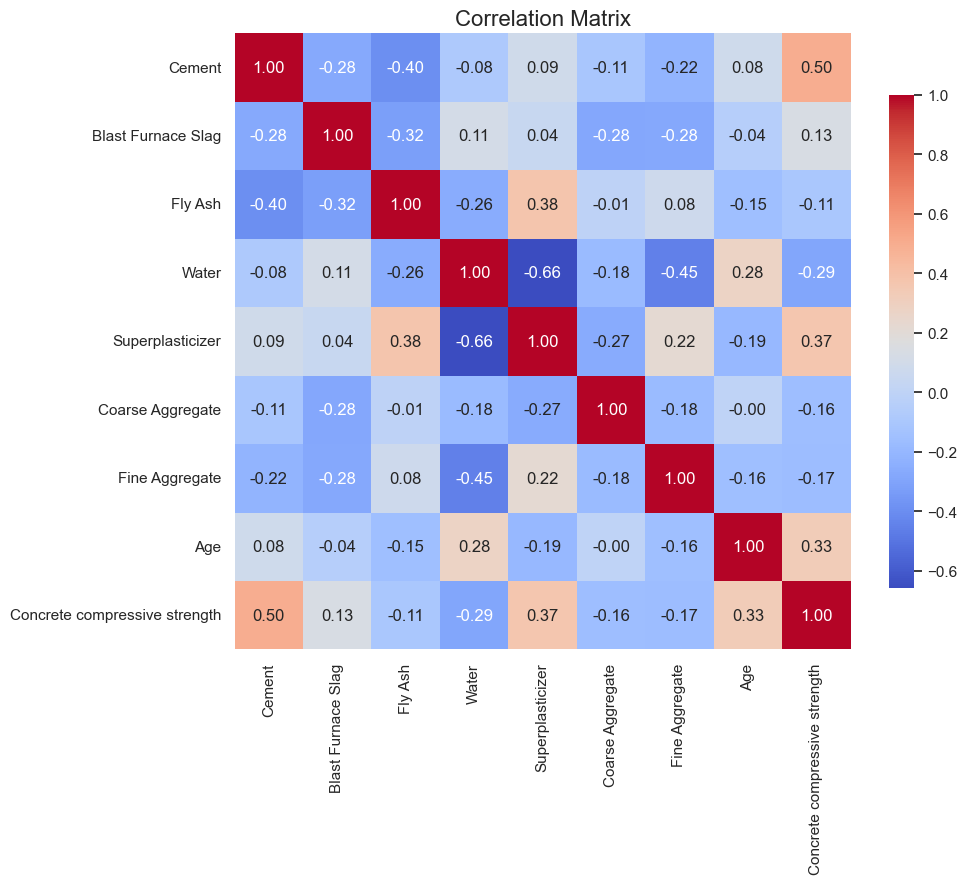

In [8]:
# Correlation matrix
df.columns = [col.split('(')[0].strip() for col in df.columns]
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix", fontsize=16)



In [9]:
# Flatten correlation matrix and sort
correlations = corr_matrix.unstack().sort_values(ascending=False)

# Remove self-correlations (1s)
correlations_no_self = correlations[correlations != 1]

# Select correlations using slicing [1:9:2]
selected = correlations_no_self.iloc[1:9:2]

# Drop the second value in this selection (index 1 of 'selected')
result = selected.drop(selected.index[1])

print(result)


Cement                         Concrete compressive strength    0.497833
Concrete compressive strength  Superplasticizer                 0.366102
Age                            Concrete compressive strength    0.328877
dtype: float64


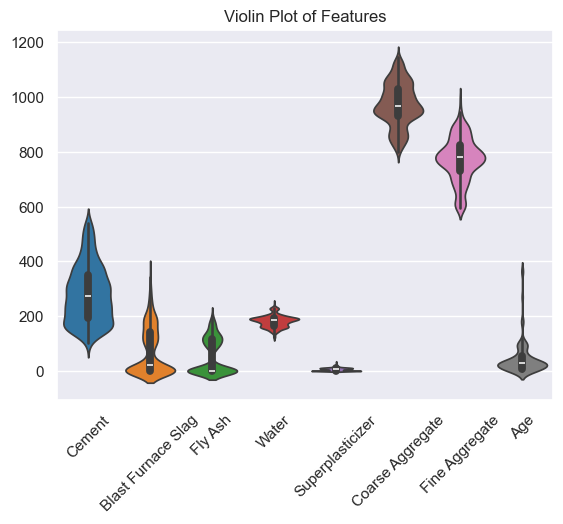

In [10]:
sns.violinplot(data=X, palette=colors)
plt.title("Violin Plot of Features")
plt.xticks(rotation=45)
plt.show()

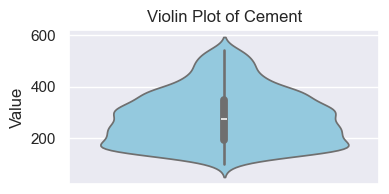

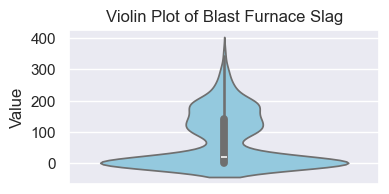

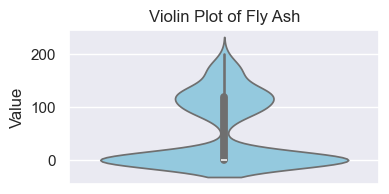

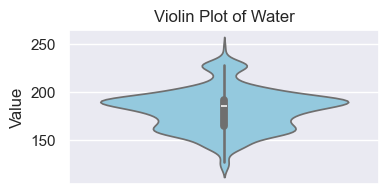

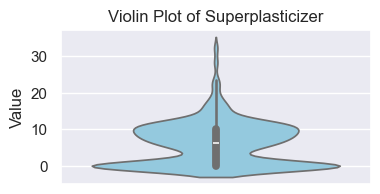

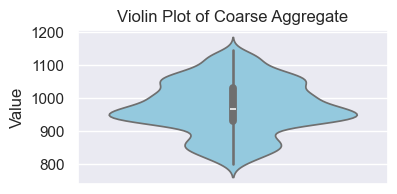

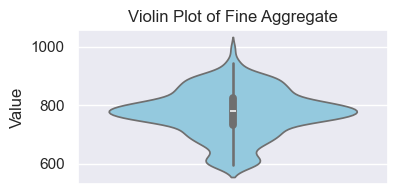

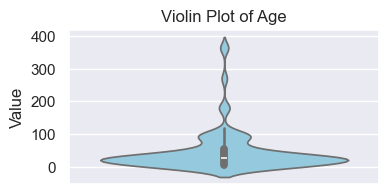

In [11]:
for col in X.columns:
    plt.figure(figsize=(4,2))
    sns.violinplot(y=X[col], color='skyblue')  
    plt.title(f"Violin Plot of {col}")
    plt.ylabel('Value')
    plt.show()
    plt.close()


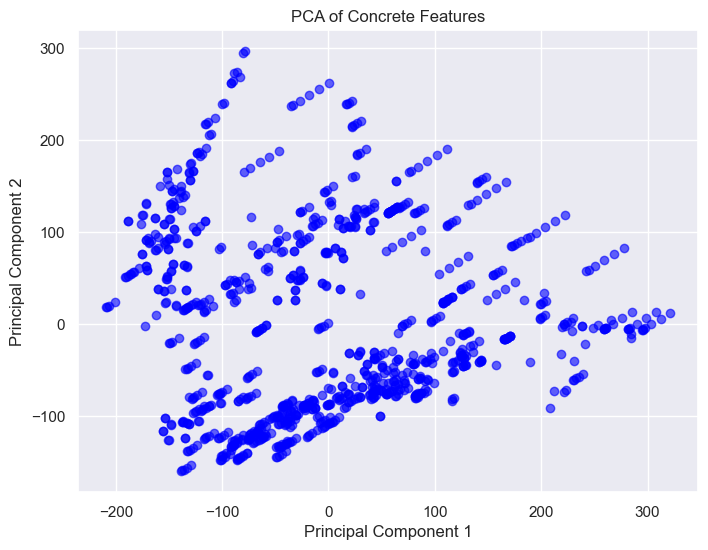

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Concrete Features')
plt.show()